# Modelling - the target model (B)

Training the **target model B** and comparing it with baseline model A (logistic regression, saved in `02-feature_engineering.ipynb`).

Three **tree-based** families compete: **RandomForest, GradientBoosting (histogram-based) and XGBoost**. Hyperparameters are tuned with 3-fold cross-validation scored by `average_precision` (bookings are very rare). As a **side experiment** we also check whether feature selection changes anything. The best model is saved as `model_b_pipeline.joblib` and becomes variant **B** in the microservice A/B test.

By design, the model's output is an additional term in the ranking score:

$$FinalScore = W_A \times BaseScore + W_B \times P(Y=1|X)$$

In [5]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, classification_report,
)
from xgboost import XGBClassifier

df = pd.read_csv("../data/processed/training_data.csv")
print(f"Zbiór danych: {df.shape}")
df.head()

Zbiór danych: (317277, 32)


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,room_type,accommodates,bedrooms,price,neighbourhood_cleansed,host_is_superhost,host_acceptance_rate,minimum_nights,minimum_maximum_nights,bathrooms
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,2.0,1.0,812.0,Bispebjerg,No,69.0,1.0,30.0,1.0
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,3.0,3.0,1359.0,Vesterbro-Kongens Enghave,Unknown,73.0,2.0,115.0,1.0
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,3.0,1.0,1200.0,Indre By,No,73.0,3.0,31.0,1.0
3,162656,2009-11-18 03:39:25.925930,976307,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,5.0,3.0,2821.0,Unknown,Unknown,88.0,2.0,30.0,1.0
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,2.0,1.0,629.0,Vesterbro-Kongens Enghave,Yes,99.0,3.0,31.0,1.0


## Data preparation

Identifier columns are dropped and `Y` is separated from the features. The train/test split is stratified, because the classes are heavily imbalanced.

Preprocessing for tree models is minimal: median imputation (a guard against missing values) plus one-hot encoding for categoricals. Scaling and winsorisation are unnecessary - trees split on thresholds, so they are insensitive to scale and to outliers.


In [6]:
drop_cols = ['user_id', 'timestamp', 'listing_id']
df = df.drop(columns=drop_cols)

y = df['Y'].astype(int)
X = df.drop(columns=['Y'])

cat_cols = ['property_type', 'room_type', 'neighbourhood_cleansed', 'host_is_superhost']
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Trening: {X_train.shape}, Test: {X_test.shape}")
print(f"Udział Y=1 w treningu: {y_train.mean():.4f}")
print(f"Udział Y=1 w teście:   {y_test.mean():.4f}")


Trening: (253821, 28), Test: (63456, 28)
Udział Y=1 w treningu: 0.0073
Udział Y=1 w teście:   0.0073


Preprocessing for tree models: median imputation + one-hot encoding of categoricals.

Trees need neither scaling nor outlier removal (they split on thresholds), so
there is no point in scaling or winsorising price.

In [7]:
pre_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

## Model competition + hyperparameter tuning

Three tree families are compared (RandomForest, GradientBoosting, XGBoost). Logistic regression is the baseline. SVM is unsuitable at this level of class imbalance.

Each family is tuned with `RandomizedSearchCV`, scored by `average_precision`, with **3-fold** cross-validation. The grids are deliberately small because of hardware constraints. Class imbalance is handled with `class_weight='balanced'` (or `scale_pos_weight` for XGBoost).

In [17]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio (neg/pos): {scale_pos:.1f}")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # ten sam seed co model A.

configs = {
    'RandomForest': dict(
        pre=pre_tree,
        clf=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        params={'clf__n_estimators': [200],
                'clf__max_depth': [12, 18],
                'clf__min_samples_leaf': [20, 50],
                'clf__max_features': ['sqrt']},
        n_iter=4,   # z 4 kombinacji (RF najdroższy obliczeniowo)
    ),
    'GradientBoosting': dict(
        pre=pre_tree,
        clf=HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
        params={'clf__learning_rate': [0.03, 0.05, 0.1],
                'clf__max_depth': [3, 6, 9],
                'clf__max_iter': [200, 300, 400],
                'clf__max_leaf_nodes': [31, 63],
                'clf__l2_regularization': [0.0, 1.0],
                'clf__min_samples_leaf': [20, 50]},
        n_iter=12,   # z 216 kombinacji
    ),
    'XGBoost': dict(
        pre=pre_tree,
        clf=XGBClassifier(eval_metric='logloss', tree_method='hist',
                          scale_pos_weight=scale_pos, random_state=42, n_jobs=-1),
        params={'clf__n_estimators': [200, 400, 600],
                'clf__max_depth': [4, 6, 8],
                'clf__learning_rate': [0.03, 0.05, 0.1],
                'clf__subsample': [0.8, 1.0],
                'clf__colsample_bytree': [0.8, 1.0],
                'clf__min_child_weight': [1, 5],
                'clf__reg_lambda': [1.0, 5.0]},
        n_iter=12,   # z 648 kombinacji
    ),
}

results = {}
for name, cfg in configs.items():
    print(f"=== {name} ===")
    pipe = Pipeline([('pre', cfg['pre']), ('clf', cfg['clf'])])
    search = RandomizedSearchCV(pipe, cfg['params'], n_iter=cfg['n_iter'],
                                scoring='average_precision', cv=cv,
                                random_state=42, n_jobs=-1, refit=True)
    search.fit(X_train, y_train)
    proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    results[name] = {
        'estimator': search.best_estimator_,
        'cv_ap': search.best_score_,
        'test_ap': average_precision_score(y_test, proba),
        'test_auc': roc_auc_score(y_test, proba),
        'best_params': search.best_params_,
    }
    print(f"  CV AP={search.best_score_:.4f}  Test AP={results[name]['test_ap']:.4f}  Test AUC={results[name]['test_auc']:.4f}")

Imbalance ratio (neg/pos): 136.7
=== RandomForest ===
  CV AP=0.0422  Test AP=0.0330  Test AUC=0.7463
=== GradientBoosting ===
  CV AP=0.0416  Test AP=0.0335  Test AUC=0.7463
=== XGBoost ===
  CV AP=0.0415  Test AP=0.0354  Test AUC=0.7535


## Selecting model B

The families are compared by Average Precision on the test set, and the best one becomes target model B.

In [18]:
res_df = pd.DataFrame({
    k: {'CV AP': v['cv_ap'], 'Test AP': v['test_ap'], 'Test ROC-AUC': v['test_auc']}
    for k, v in results.items()
}).T.sort_values('Test AP', ascending=False)
print("Porównanie modeli (sort: Test AP):")
display(res_df.round(4))

best_name = res_df.index[0]
print(f"\nNajlepszy model B: {best_name}")
print(f"Hiperparametry: {results[best_name]['best_params']}")

Porównanie modeli (sort: Test AP):


,CV AP,Test AP,Test ROC-AUC
XGBoost,0.0415,0.0354,0.7535
GradientBoosting,0.0416,0.0335,0.7463
RandomForest,0.0422,0.0330,0.7463



Najlepszy model B: XGBoost
Hiperparametry: {'clf__subsample': 1.0, 'clf__reg_lambda': 5.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 4, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}


## Comparing model A and model B

For the comparison to be fair, baseline model A is trained **on the same `X_train`** as model B and evaluated on the untouched `X_test`. (The saved `model_a_pipeline.joblib` artifact from `02` is trained on all the data - it exists only for serving, not for evaluation, because it has seen `X_test`.)

Model A is defined exactly as in feature engineering: median imputation + scaling of all numeric features + one-hot encoding of categoricals + logistic regression with `class_weight='balanced'`.

In [20]:
# Model A trained fairly on X_train (like model B), evaluated on X_test.
preprocess_a = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])
model_a = Pipeline([('pre', preprocess_a),
                    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
model_a.fit(X_train, y_train)
model_b = results[best_name]['estimator']

proba_a = model_a.predict_proba(X_test)[:, 1]
proba_b = model_b.predict_proba(X_test)[:, 1]

compare = pd.DataFrame({
    'model A (LogisticRegression)': {
        'ROC-AUC': roc_auc_score(y_test, proba_a),
        'Average Precision': average_precision_score(y_test, proba_a),
    },
    f'model B ({best_name})': {
        'ROC-AUC': roc_auc_score(y_test, proba_b),
        'Average Precision': average_precision_score(y_test, proba_b),
    },
}).T
display(compare.round(4))

print("\nModel B - raport klasyfikacji (próg 0.5):")
print(classification_report(y_test, model_b.predict(X_test), target_names=['No Booking', 'Booking']))

,ROC-AUC,Average Precision
model A (LogisticRegression),0.7240,0.0277
model B (XGBoost),0.7535,0.0354



Model B - raport klasyfikacji (próg 0.5):
              precision    recall  f1-score   support

  No Booking       1.00      0.80      0.89     62995
     Booking       0.02      0.59      0.04       461

    accuracy                           0.80     63456
   macro avg       0.51      0.70      0.46     63456
weighted avg       0.99      0.80      0.88     63456



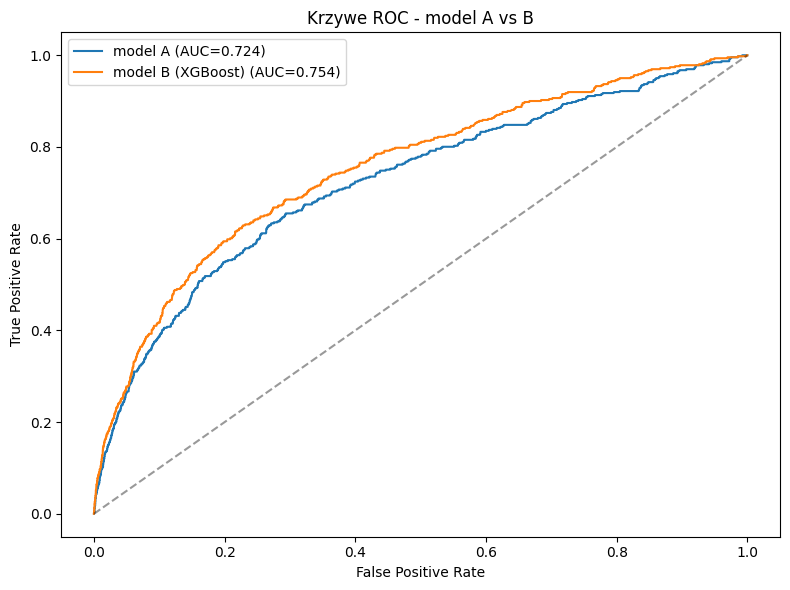

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
for label, proba in [('model A', proba_a), (f'model B ({best_name})', proba_b)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Krzywe ROC - model A vs B')
ax.legend()
plt.tight_layout()
plt.show()

## Feature importance

Feature importance is taken from the RandomForest model - it always competes and exposes `feature_importances_`, so it gives a readable view regardless of which family won as model B.

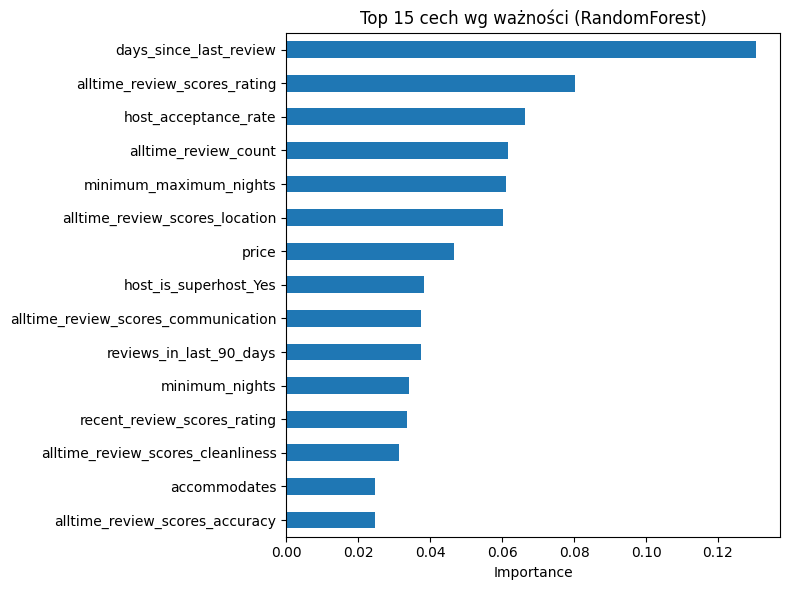

In [22]:
rf_model = results['RandomForest']['estimator']
clf = rf_model.named_steps['clf']
feat_names = rf_model.named_steps['pre'].get_feature_names_out()

# Strip ColumnTransformer prefixes (price__, num__, cat__) for readability
clean_names = [name.split('__', 1)[-1] for name in feat_names]
importances = pd.Series(clf.feature_importances_, index=clean_names)
top = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
top.plot(kind='barh', ax=ax)
ax.set_title('Top 15 cech wg ważności (RandomForest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Predictions and saved artifacts

The winning model B is retrained **from scratch on all the data** (train+test) - evaluation has already happened, so deployment uses the maximum amount of data. The model is saved as a self-contained pipeline, and predictions from both saved models (A and B) are generated on the inference sample - exactly as the microservice does it.

In [23]:
from sklearn.base import clone

X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

# clone() -> a fresh, untrained estimator with the same hyperparameters.
# This avoids mutating the object in results, so the A/B comparison cell can be
# re-run safely - it must see model B trained on X_train only.
model_b_final = clone(results[best_name]['estimator']).fit(X_all, y_all)
print(f"Model B ({best_name}) ponownie wytrenowany na wszystkich danych.")

os.makedirs("../data/processed", exist_ok=True)
joblib.dump(model_b_final, "../data/processed/model_b_pipeline.joblib")
print("Zapisano model docelowy → data/processed/model_b_pipeline.joblib")

Model B (XGBoost) ponownie wytrenowany na wszystkich danych.
Zapisano model docelowy → data/processed/model_b_pipeline.joblib


In [24]:
inference_df = pd.read_csv("../data/processed/inference_sample.csv")
inf_ids = inference_df[['user_id', 'timestamp', 'listing_id']].copy()
feat_cols = [c for c in inference_df.columns if c not in ['user_id', 'timestamp', 'listing_id', 'Y']]
X_inf = inference_df[feat_cols]

# Use the SAVED artifacts (trained on all the data), exactly as the microservice does
served_a = joblib.load("../data/processed/model_a_pipeline.joblib")
served_b = joblib.load("../data/processed/model_b_pipeline.joblib")

inf_ids['prob_model_A'] = served_a.predict_proba(X_inf)[:, 1]
inf_ids['prob_model_B'] = served_b.predict_proba(X_inf)[:, 1]

inf_ids.to_csv("../data/processed/inference_predictions.csv", index=False)
print(f"Predykcje inferencyjne: {inf_ids.shape}")
print("\nRozkład prawdopodobieństw (model A):")
print(inf_ids['prob_model_A'].describe())
print("\nRozkład prawdopodobieństw (model B):")
print(inf_ids['prob_model_B'].describe())
inf_ids.sort_values('prob_model_B', ascending=False).head(10)

Predykcje inferencyjne: (508, 5)

Rozkład prawdopodobieństw (model A):
count    508.000000
mean       0.460573
std        0.199727
min        0.069639
25%        0.312803
50%        0.400519
75%        0.582740
max        0.990324
Name: prob_model_A, dtype: float64

Rozkład prawdopodobieństw (model B):
count    508.000000
mean       0.431932
std        0.209200
min        0.055350
25%        0.277601
50%        0.377642
75%        0.574832
max        0.957167
Name: prob_model_B, dtype: float64


,user_id,timestamp,listing_id,prob_model_A,prob_model_B
7,485359583,2025-08-09 23:44:32.522071,10645628,0.954737,0.957167
94,34068089,2025-08-14 01:38:51.077128,6689857,0.956664,0.940013
499,37996318,2025-09-05 19:42:34.047350,42560475,0.981469,0.927682
344,375313259,2025-08-25 18:42:52.216563,23495332,0.990324,0.926257
444,90260624,2025-08-31 06:48:42.414944,20223600,0.964676,0.925430
249,558848637,2025-08-21 12:39:58.359285,16809364,0.887053,0.913808
376,710318177,2025-08-26 17:49:16.782989,37182790,0.970674,0.913014
64,153853500,2025-08-12 10:09:22.152291,1055721775475789440,0.971142,0.909113
439,6882960,2025-08-30 05:32:23.153638,9054276,0.935517,0.903280
107,148648748,2025-08-14 10:40:20.817553,6181515,0.962178,0.900773


## Conclusions

- Three tree families were compared (RandomForest, GradientBoosting, XGBoost), tuned with 3-fold cross-validation (scoring = Average Precision; a small grid because of hardware constraints). Logistic regression is baseline model A and is not repeated in the competition.
- **XGBoost wins** (Test AP ~ 0.0354, Test ROC-AUC ~ 0.754), ahead of GradientBoosting (0.0335 / 0.746) and RandomForest (0.0330 / 0.746). XGBoost therefore becomes target model B.
- A methodological caveat: the model is selected on `Test AP`, so that figure is slightly optimistic. The more "blind" measure is CV AP, where the three families are practically tied (0.0415-0.0422) - the differences are small, and the holdout is what settles the choice of XGBoost.
- In the comparison, baseline model A is trained **on `X_train`** (like model B) and evaluated on `X_test`, with no leakage. The saved A artifact (trained on all the data) is for serving only.
- Feature selection (`SelectFromModel`) was only a **side experiment** - it does not improve the result (AP after cutting ~half the features is essentially the same as with the full set), so the final model B deliberately uses all features.
- Both models are saved as self-contained pipelines (`model_a_pipeline.joblib`, `model_b_pipeline.joblib`), so the microservice loads them without knowing any preprocessing details.
- The absolute AP level (~0.035) stays low - this is the **signal ceiling in the data**, not a limitation of the model. Hyperparameter tuning buys fractions; a real jump would require better features (user x listing interactions, session history). The low precision on the `Booking` class follows from the extreme imbalance; the model serves as a **ranking component** (P(Y=1|X) used for reordering), where ROC-AUC and AP are the appropriate measures.
- Predictions from both models on the inference sample are saved in `inference_predictions.csv`.